<a href="https://colab.research.google.com/github/LaisSilva42/Analise-cluster/blob/main/Clusteriza%C3%A7%C3%A3o.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabalho Final - Pesquisa de Marketing

BD: https://www.kaggle.com/datasets/zeesolver/consumer-behavior-and-shopping-habits-dataset



---


Para esta pesquisa, utilizamos um conjunto de dados disponível na plataforma Kaggle, que
contém informações detalhadas sobre as compras de clientes de uma loja de moda. O
conjunto de dados foi escolhido por sua relevância e abrangência, permitindo uma análise
profunda do comportamento dos consumidores da FashionLux. O método de coleta dos dados
envolveu o registro das transações de compras realizadas pelos clientes, abrangendo diversas
variáveis que são essenciais para a análise de clusterização.


**Introdução**

No mercado competitivo de moda dos Estados Unidos, entender o comportamento dos
consumidores é crucial para o sucesso das empresas. A "FashionLux", uma empresa fictícia
americana especializada na venda de roupas, agasalhos e calçados, busca aprimorar suas
estratégias de marketing para melhor atender às necessidades e preferências de seus clientes.
Com uma vasta gama de produtos que atende a diversas faixas etárias e estilos , a FashionLux
deseja explorar dados de compras de seus clientes para identificar padrões de comportamento
e segmentar seu público de forma eficaz.

**Objetivo**

O objetivo desta pesquisa é aplicar técnicas de clusterização para segmentar a base de clientes
da FashionLux em quatro grupos distintos. Através dessa análise, pretendemos identificar
grupos de clientes com comportamentos de compra semelhantes, o que permitirá à empresa
personalizar suas campanhas de marketing, ajustar seu estoque e aprimorar a experiência de
compra.

Outros pontos importantes da nossa pesquisa são :

● Analisar a distribuição demográfica dos consumidores: Identificar como diferentes
grupos de clientes se distribuem em termos de idade, gênero e localização.

● Entender as preferências de compra: Determinar quais categorias de produtos
(roupas, agasalhos, calçados) são mais populares entre os diferentes clusters de
clientes.

● Avaliar métodos de pagamento e frequência de compras: Investigar as
preferências dos clientes em relação aos métodos de pagamento e a frequência com
que realizam compras.

Através desta análise, esperamos fornecer insights valiosos para a FashionLux, permitindo
uma abordagem de marketing mais segmentada e eficiente.

**Método de Análise**

Clusterização : para segmentar a base de clientes da FashionLux,
utilizamos o algoritmo de K-means para clusterização. Este método permite agrupar clientes com base em características semelhantes, ajudando a identificar padrões de comportamento.

Após a clusterização, foi selecionada uma amostra dos 4 estados com maior índice de clientes para realizar as análises.


In [ ]:
#Importando pacotes

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

## Pré processamento

In [ ]:
#importando base de dados e visualizando-a

df = pd.read_csv('/content/shopping_behavior_updated.csv')
df

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,2-Day Shipping,No,No,32,Venmo,Weekly
3896,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3897,3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Standard,No,No,24,Venmo,Quarterly
3898,3899,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,Express,No,No,24,Venmo,Weekly


In [ ]:
# Checando se todas as colunas estão preenchidas

df.isnull().sum()

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

In [ ]:
#Selecionando Variáveis Utilizadas para a Clusterização

df_selected = df[['Age', 'Gender','Category', 'Purchase Amount (USD)', 'Location',
                  'Review Rating', 'Subscription Status', 'Discount Applied', 'Promo Code Used',
                  'Previous Purchases','Payment Method','Frequency of Purchases']]
df_selected.head()

,Age,Gender,Category,Purchase Amount (USD),Location,Review Rating,Subscription Status,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,55,Male,Clothing,53,Kentucky,3.1,Yes,Yes,Yes,14,Venmo,Fortnightly
1,19,Male,Clothing,64,Maine,3.1,Yes,Yes,Yes,2,Cash,Fortnightly
2,50,Male,Clothing,73,Massachusetts,3.1,Yes,Yes,Yes,23,Credit Card,Weekly
3,21,Male,Footwear,90,Rhode Island,3.5,Yes,Yes,Yes,49,PayPal,Weekly
4,45,Male,Clothing,49,Oregon,2.7,Yes,Yes,Yes,31,PayPal,Annually


**Descrição dos Dados Selecionados**

O conjunto de dados inclui as seguintes variáveis:

● Age: A idade do cliente.

● Gender: O gênero do cliente (Masculino ou Feminino).

● Category: A categoria do produto comprado (Roupas, Agasalhos, Calçados).

● Purchase Amount: O valor gasto na compra, medido em dólares.

● Location: A localização geográfica do cliente.

● Review Rating: nota de 0 a 5 estrelas

●Subscription Status: se está inscrito em algum email/promoção

●Discount Applied: Desconto Aplicado

●Promo Code Used: Cupom de promoção usado

●Previous Purchases: compras feitas anteriormente

● Payment Method: O método de pagamento utilizado (Cartão de Crédito, Débito,
Dinheiro, etc.).

● Frequency of Purchases: A frequência com que o cliente realiza compras (Mensal, Trimestral, Anual, etc.).

In [ ]:
# One hot enconding

df_encoded = pd.get_dummies(df_selected, columns=['Subscription Status', 'Discount Applied', 'Promo Code Used','Gender','Category','Location','Payment Method','Frequency of Purchases'], dtype= int)
df_encoded.head()

,Age,Purchase Amount (USD),Review Rating,Previous Purchases,Subscription Status_No,Subscription Status_Yes,Discount Applied_No,Discount Applied_Yes,Promo Code Used_No,Promo Code Used_Yes,...,Payment Method_Debit Card,Payment Method_PayPal,Payment Method_Venmo,Frequency of Purchases_Annually,Frequency of Purchases_Bi-Weekly,Frequency of Purchases_Every 3 Months,Frequency of Purchases_Fortnightly,Frequency of Purchases_Monthly,Frequency of Purchases_Quarterly,Frequency of Purchases_Weekly
0,55,53,3.1,14,0,1,0,1,0,1,...,0,0,1,0,0,0,1,0,0,0
1,19,64,3.1,2,0,1,0,1,0,1,...,0,0,0,0,0,0,1,0,0,0
2,50,73,3.1,23,0,1,0,1,0,1,...,0,0,0,0,0,0,0,0,0,1
3,21,90,3.5,49,0,1,0,1,0,1,...,0,1,0,0,0,0,0,0,0,1
4,45,49,2.7,31,0,1,0,1,0,1,...,0,1,0,1,0,0,0,0,0,0


In [ ]:
# Padronizando os dados com a mesma unidade de medida

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_encoded)
print("\nDataFrame escalado:\n", df_scaled)


DataFrame escalado:
 [[ 0.71891344 -0.28562864 -0.90758357 ... -0.40647581 -0.4107486
  -0.40046091]
 [-1.64862924  0.17885219 -0.90758357 ... -0.40647581 -0.4107486
  -0.40046091]
 [ 0.39008807  0.55888195 -0.90758357 ... -0.40647581 -0.4107486
   2.49712265]
 ...
 [ 0.12702777 -1.13013923 -1.18686209 ... -0.40647581  2.43457919
  -0.40046091]
 [-0.00450238  0.72778407  0.06989124 ... -0.40647581 -0.4107486
   2.49712265]
 [ 0.52161822  0.89668619 -0.90758357 ... -0.40647581  2.43457919
  -0.40046091]]


## Aplicação kmeans

In [ ]:
# Aplicando KMeans
kmeans = KMeans(n_clusters=4, random_state=0)
kmeans.fit(df_scaled)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


KMeans(n_clusters=4, random_state=0)

In [ ]:
# Adicionando os rótulos dos clusters ao DataFrame original
df_selected['Cluster'] = kmeans.labels_

<ipython-input-64-5abc89a0342a>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_selected['Cluster'] = kmeans.labels_


## Análise dos dados

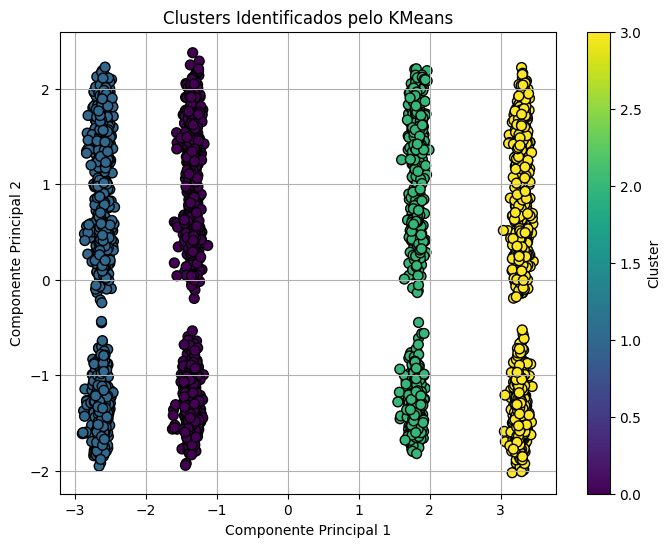

In [ ]:
# Reduzindo a dimensionalidade para plotagem usando PCA
pca = PCA(n_components=2)
principal_components = pca.fit_transform(df_scaled)

# Plotando os clusters
plt.figure(figsize=(8, 6))

# Criando um scatter plot
plt.scatter(principal_components[:, 0], principal_components[:, 1], c=df_selected['Cluster'], cmap='viridis', edgecolor='k', s=50)
plt.title('Clusters Identificados pelo KMeans')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.colorbar(label='Cluster')
plt.grid(True)
plt.show()

**Elementos do Gráfico:**

○ Pontos: Cada ponto no gráfico representa um dado do conjunto
original, reduzido para duas dimensões usando PCA.

○ Cores: As cores dos pontos indicam a qual cluster cada ponto pertence, conforme identificado pelo algoritmo KMeans.

○ Barra de Cores: À direita do gráfico, a barra de cores mostra a correspondência entre as cores e os clusters (0 a 3). Interpretação

**Interpretação**

● Clusters: O gráfico mostra quatro clusters distintos, cada um com uma cor diferente. Isso indica que o algoritmo KMeans identificou quatro grupos principais nos dados.

● Distribuição: A distribuição dos pontos em cada cluster mostra como os dados se agrupam em torno de certas características principais, representadas pelas componentes principais 1 e 2.

● Separação: A separação entre os clusters sugere que os dados possuem características distintas que permitem essa divisão clara.

**Utilidade:** Este gráfico é útil para visualizar como os dados foram agrupados pelo algoritmo KMeans após a redução de dimensionalidade com PCA. Ele ajuda a entender a estrutura dos dados e a eficácia do algoritmo de clustering.


In [ ]:
# Agrupamento por Cluster - Variáveis Qualitativas

df_selected[['Subscription Status', 'Discount Applied', 'Promo Code Used', 'Cluster']].groupby(['Cluster']).value_counts()

Cluster  Subscription Status  Discount Applied  Promo Code Used
0        No                   No                No                  975
1        No                   No                No                 1248
2        No                   Yes               Yes                 624
3        Yes                  Yes               Yes                1053
Name: count, dtype: int64

Cluster 0: Os consumidores não têm status de assinatura, desconto aplicado ou código promocional usado, e totalizam 975 clientes.

Cluster 1: Similar ao Cluster 0, mas com uma contagem maior de 1248 clientes.

Cluster 2: Neste cluster, os consumidores não têm status de assinatura, mas têm desconto aplicado e código promocional usado, totalizando 624 clientes.

Cluster 3: Todos os dados neste cluster têm status de assinatura, desconto aplicado e código promocional usado, com uma contagem de 1053 clientes.


In [ ]:
# Dividindo os clusters para análise

df0 = df_selected[df_selected['Cluster'] == 0]
df1 = df_selected[df_selected['Cluster'] == 1]
df2 = df_selected[df_selected['Cluster'] == 2]
df3 = df_selected[df_selected['Cluster'] == 3]


### Cluster 0


O Cluster 0, com 975 clientes, são mais presentes nos seguintes estados: Alabama, California, New York e Vermont. Eles representam um perfil de consumidores composto por homens com idade média de 43 anos. Estes consumidores realizaram, em média, 26 compras anteriormente, com um ticket médio de $ 57,12 por compra. Entretanto, é importante ressaltar o alto índice do desvio padrão para estas variáveis. A avaliação média dada por estes consumidores é de 3,9 estrelas. O método de pagamento preferido por este grupo é o PayPal. As categorias de produtos mais compradas são roupas, 45.8% , seguidas por acessórios, 34.6%. Este grupo não costuma utilizar descontos, cupons ou inscrições em promoções. A maioria dos consumidores deste perfil realiza compras semanalmente.

In [ ]:
df0.head()

,Age,Gender,Category,Purchase Amount (USD),Location,Review Rating,Subscription Status,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases,Cluster
1677,65,Male,Clothing,35,Oregon,3.3,No,No,No,41,Debit Card,Weekly,0
1678,41,Male,Clothing,71,Ohio,4.8,No,No,No,30,Venmo,Fortnightly,0
1679,60,Male,Clothing,52,Massachusetts,4.5,No,No,No,24,Debit Card,Bi-Weekly,0
1680,61,Male,Footwear,37,Louisiana,3.4,No,No,No,6,Credit Card,Annually,0
1681,24,Male,Footwear,95,Virginia,3.7,No,No,No,14,Credit Card,Bi-Weekly,0


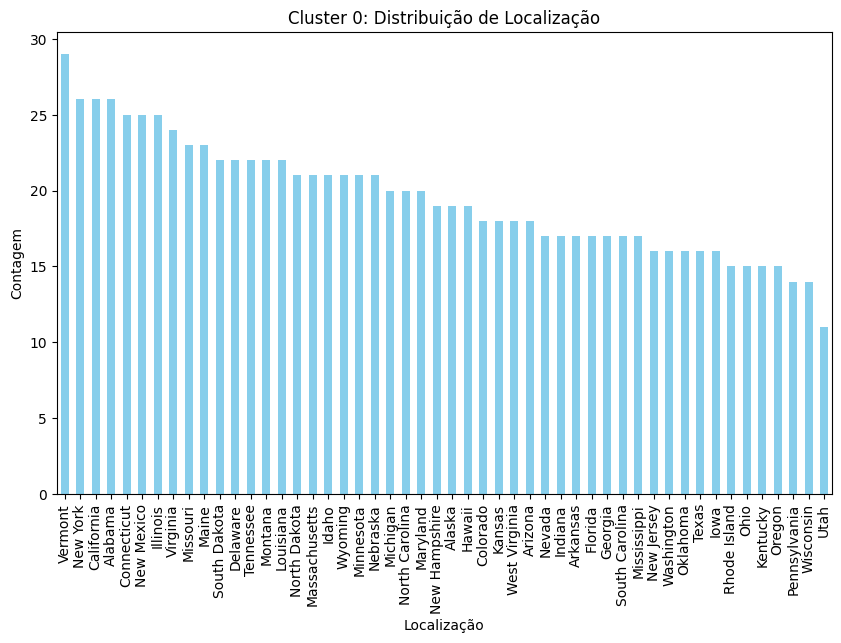

In [ ]:
# Contar a frequência de compra de cada localização
frequencia_location = df0['Location'].value_counts()

# Plotar o gráfico de colunas
plt.figure(figsize=(10, 6))
frequencia_location.plot(kind='bar', color='skyblue')
plt.title('Cluster 0: Distribuição de Localização')
plt.xlabel('Localização')
plt.ylabel('Contagem')
plt.xticks(rotation=90)
plt.show()

In [ ]:
# Analisando amostra de acordo com os 4 estados com mais compras

estados = ['Vermont', 'New York', 'California', 'Alabama']

df0_amostra = df0[df0['Location'].isin(estados)]

df0_amostra.describe()

,Age,Purchase Amount (USD),Review Rating,Previous Purchases,Cluster
count,107.000000,107.000000,107.000000,107.000000,107.0
mean,43.607477,57.121495,3.899065,25.822430,0.0
std,16.299529,24.868223,0.671171,14.609904,0.0
min,18.000000,20.000000,2.600000,1.000000,0.0
25%,28.500000,34.000000,3.400000,13.000000,0.0
50%,42.000000,56.000000,3.900000,26.000000,0.0
75%,58.000000,80.000000,4.450000,38.500000,0.0
max,70.000000,99.000000,5.000000,50.000000,0.0


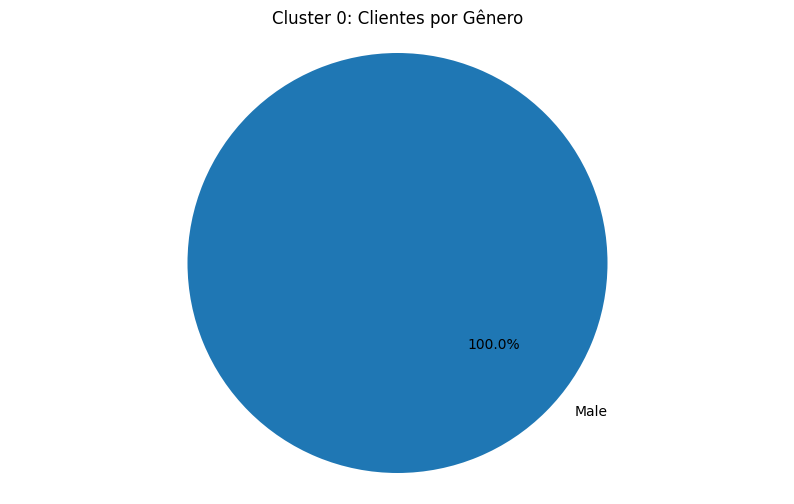

In [ ]:
# Contar a frequência de cada gênero
frequencia_genero = df0_amostra['Gender'].value_counts()

# Plotar o gráfico de pizza
plt.figure(figsize=(10, 6))
plt.pie(frequencia_genero, labels=frequencia_genero.index, autopct='%1.1f%%', startangle=140)
plt.title('Cluster 0: Clientes por Gênero')
plt.axis('equal')
plt.show()

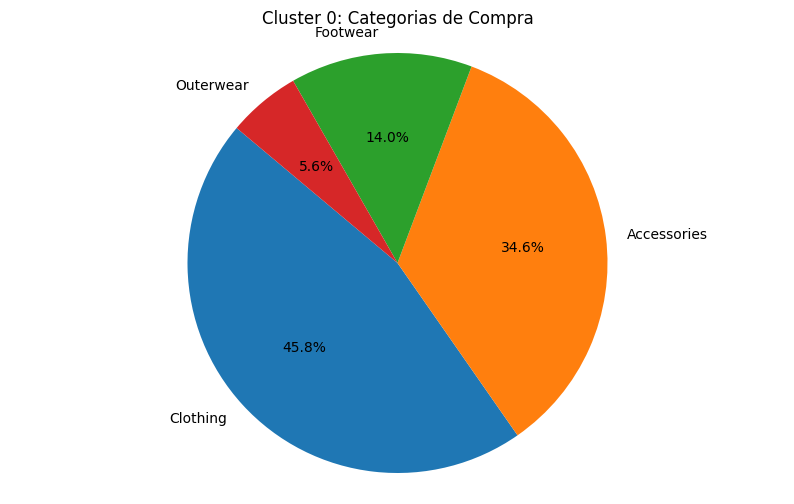

In [ ]:
# Contar a frequência de cada Categoria
frequencia_categoria = df0_amostra['Category'].value_counts()

# Plotar o gráfico de pizza
plt.figure(figsize=(10, 6))
plt.pie(frequencia_categoria, labels=frequencia_categoria.index, autopct='%1.1f%%', startangle=140)
plt.title('Cluster 0: Categorias de Compra')
plt.axis('equal')
plt.show()

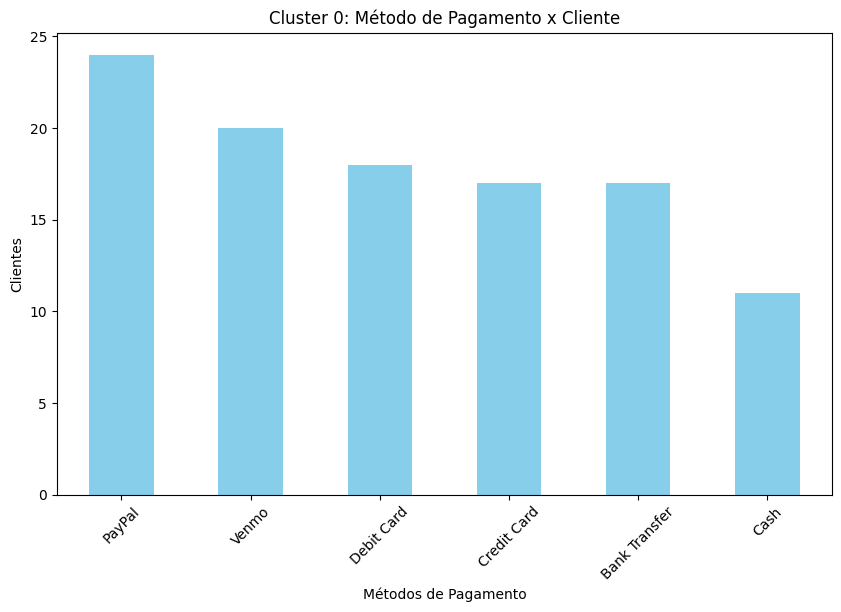

In [ ]:
# Contar a frequência de cada Método de Pagamento
frequencia_pagamento = df0_amostra['Payment Method'].value_counts()

# Plotar o gráfico de colunas
plt.figure(figsize=(10, 6))
frequencia_pagamento.plot(kind='bar', color='skyblue')
plt.title('Cluster 0: Método de Pagamento x Cliente')
plt.xlabel('Métodos de Pagamento')
plt.ylabel('Clientes')
plt.xticks(rotation=45)
plt.show()

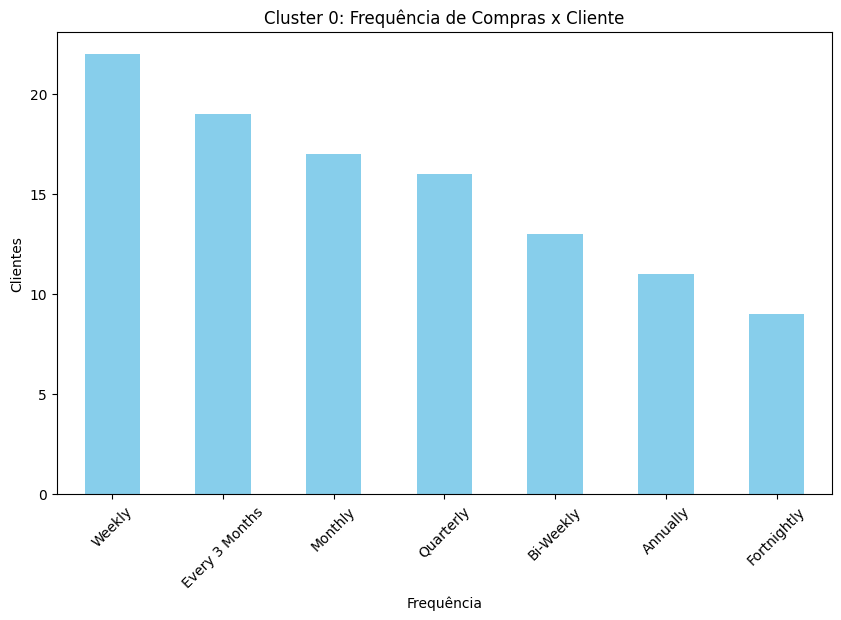

In [ ]:
# Contar a frequência de Compra
frequencia_compra = df0_amostra['Frequency of Purchases'].value_counts()

# Plotar o gráfico de colunas
plt.figure(figsize=(10, 6))
frequencia_compra.plot(kind='bar', color='skyblue')
plt.title('Cluster 0: Frequência de Compras x Cliente')
plt.xlabel('Frequência')
plt.ylabel('Clientes')
plt.xticks(rotation=45)
plt.show()

### Cluster 1

O Cluster 1, com 1248 consumidores, são mais presentes nos seguintes estados: Georgia, Idaho, Illinois, Kansas, Kentucky, Montana e Texas. Eles representam um perfil de consumidoras composto por mulheres com idade média de 43 anos. Estas consumidoras realizaram, em média, 24 compras anteriormente, com um ticket médio de $ 57,61 por compra. Entretanto, é importante ressaltar o alto índice do desvio padrão para estas variáveis. A avaliação média dada por este grupo é de 3,8 estrelas. Elas não costumam utilizar descontos, cupons ou inscrições em promoções. As categorias de produtos mais comprados são roupas e acessórios, 44.4% e 32.2%, respectivamente .O método de pagamento preferido é o Cartão de Crédito. A maioria das consumidoras deste perfil realiza compras semanalmente.

In [ ]:
df1.head()

,Age,Gender,Category,Purchase Amount (USD),Location,Review Rating,Subscription Status,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases,Cluster
2652,23,Female,Clothing,20,Maryland,3.3,No,No,No,46,Credit Card,Monthly,1
2653,67,Female,Clothing,36,Wisconsin,4.8,No,No,No,24,Venmo,Every 3 Months,1
2654,23,Female,Outerwear,70,Idaho,4.1,No,No,No,4,PayPal,Annually,1
2655,26,Female,Accessories,83,Wyoming,3.4,No,No,No,2,Credit Card,Fortnightly,1
2656,52,Female,Clothing,76,Indiana,3.6,No,No,No,29,Bank Transfer,Fortnightly,1


In [ ]:
df1.describe()

,Age,Purchase Amount (USD),Review Rating,Previous Purchases,Cluster
count,1248.000000,1248.000000,1248.000000,1248.000000,1248.0
mean,44.007212,60.249199,3.741426,24.596154,1.0
std,14.953843,23.420556,0.720625,14.579221,0.0
min,18.000000,20.000000,2.500000,1.000000,1.0
25%,31.000000,40.000000,3.100000,12.000000,1.0
50%,44.000000,60.000000,3.700000,24.000000,1.0
75%,57.000000,81.000000,4.300000,37.000000,1.0
max,70.000000,100.000000,5.000000,50.000000,1.0


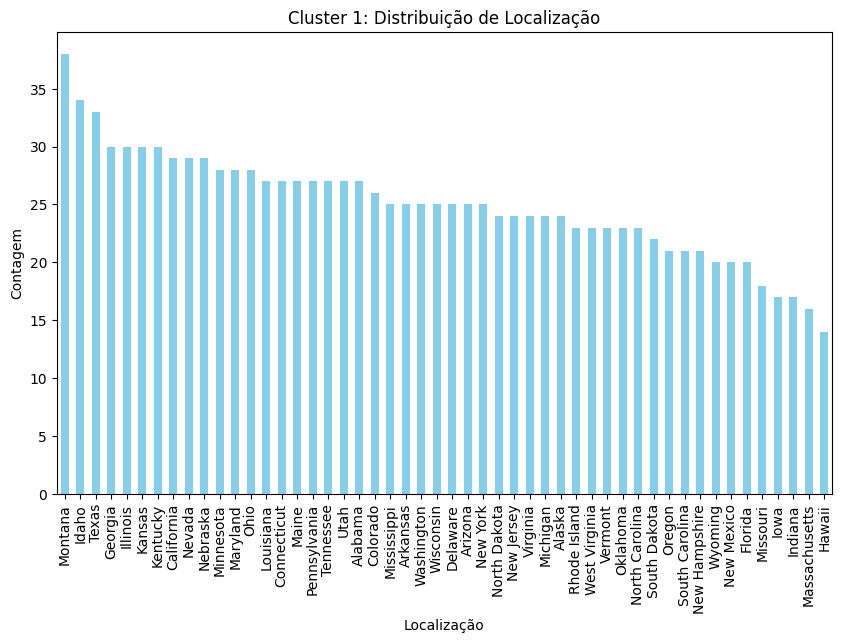

In [ ]:
# Contar a frequência de cada localização
frequencia_location = df1['Location'].value_counts()

# Plotar o gráfico de colunas
plt.figure(figsize=(10, 6))
frequencia_location.plot(kind='bar', color='skyblue')
plt.title('Cluster 1: Distribuição de Localização')
plt.xlabel('Localização')
plt.ylabel('Contagem')
plt.xticks(rotation=90)
plt.show()

In [ ]:
# Analisando amostra de acordo com os estados com os 4 maiores valores de compras (os 4 últimos possuem o mesmo valor, por isso foram inclusos)

estados = ['Montana', 'Idaho', 'Texas', 'Georgia', 'Illinois', 'Kansas', 'Kentucky']

df1_amostra = df1[df1['Location'].isin(estados)]

df1_amostra.describe()

,Age,Purchase Amount (USD),Review Rating,Previous Purchases,Cluster
count,225.000000,225.000000,225.000000,225.000000,225.0
mean,43.266667,57.613333,3.784444,24.475556,1.0
std,14.930195,23.815826,0.709362,14.775419,0.0
min,18.000000,20.000000,2.500000,1.000000,1.0
25%,31.000000,37.000000,3.200000,12.000000,1.0
50%,43.000000,57.000000,3.800000,25.000000,1.0
75%,56.000000,79.000000,4.400000,36.000000,1.0
max,70.000000,99.000000,5.000000,50.000000,1.0


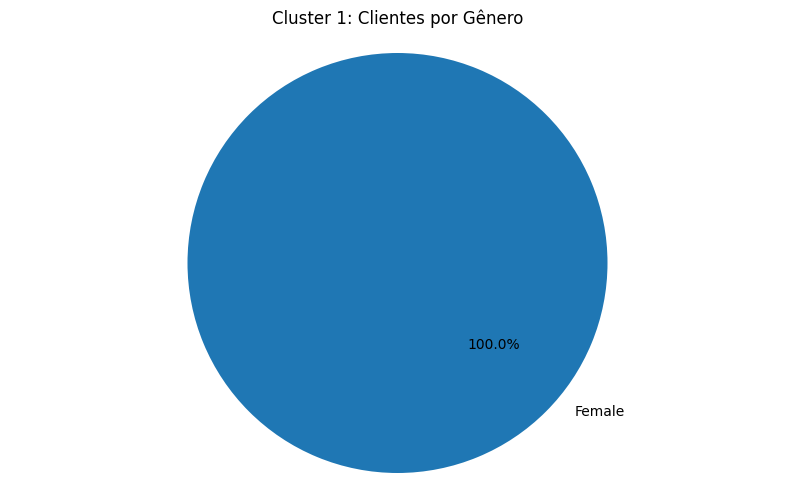

In [ ]:
# Contar a frequência de cada gênero
frequencia_genero = df1_amostra['Gender'].value_counts()

# Plotar o gráfico de pizza
plt.figure(figsize=(10, 6))
plt.pie(frequencia_genero, labels=frequencia_genero.index, autopct='%1.1f%%', startangle=140)
plt.title('Cluster 1: Clientes por Gênero')
plt.axis('equal')
plt.show()

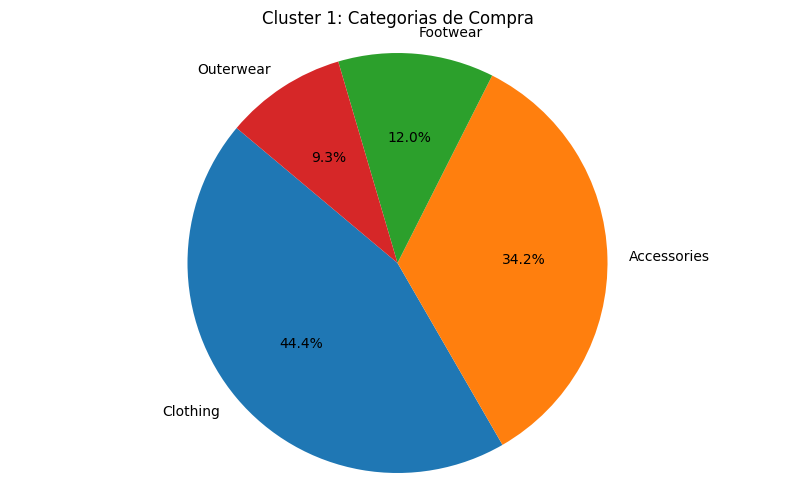

In [ ]:
# Contar a frequência de cada Categoria
frequencia_categoria = df1_amostra['Category'].value_counts()

# Plotar o gráfico de pizza
plt.figure(figsize=(10, 6))
plt.pie(frequencia_categoria, labels=frequencia_categoria.index, autopct='%1.1f%%', startangle=140)
plt.title('Cluster 1: Categorias de Compra')
plt.axis('equal')
plt.show()

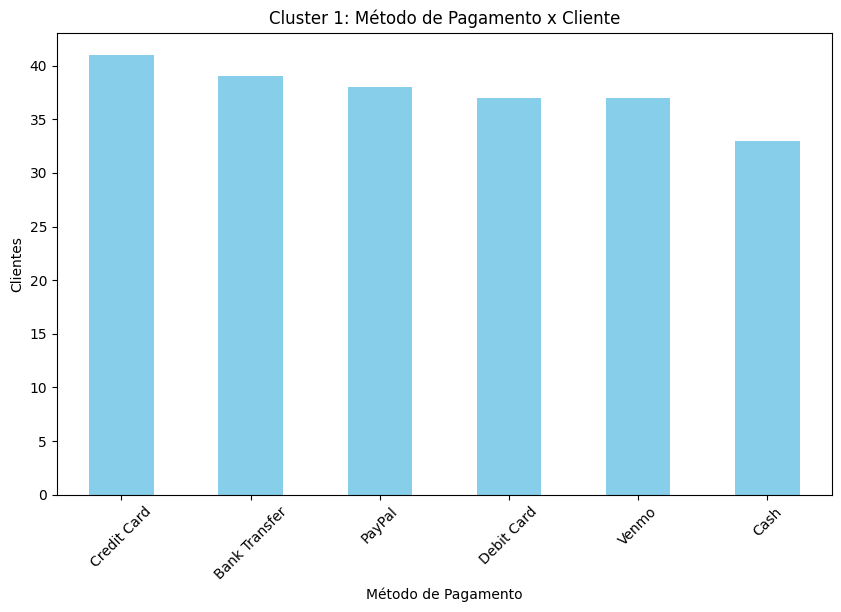

In [ ]:
# Contar a frequência de cada Método de Pagamento
frequencia_pagamento = df1_amostra['Payment Method'].value_counts()

# Plotar o gráfico de colunas
plt.figure(figsize=(10, 6))
frequencia_pagamento.plot(kind='bar', color='skyblue')
plt.title('Cluster 1: Método de Pagamento x Cliente')
plt.xlabel('Método de Pagamento')
plt.ylabel('Clientes')
plt.xticks(rotation=45)
plt.show()

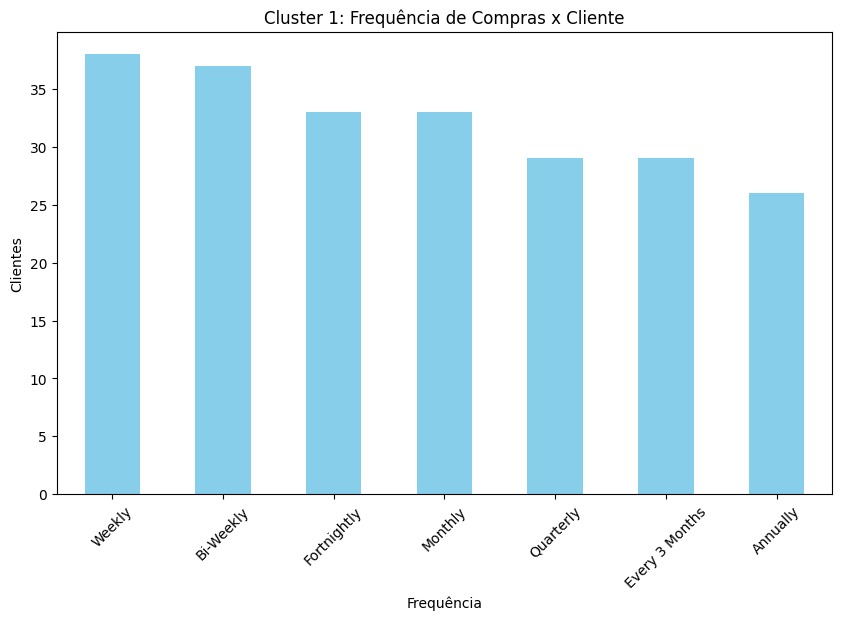

In [ ]:
# Contar a frequência de Compra
frequencia_compra = df1_amostra['Frequency of Purchases'].value_counts()

# Plotar o gráfico de colunas
plt.figure(figsize=(10, 6))
frequencia_compra.plot(kind='bar', color='skyblue')
plt.title('Cluster 1: Frequência de Compras x Cliente')
plt.xlabel('Frequência')
plt.ylabel('Clientes')
plt.xticks(rotation=45)
plt.show()

### Cluster 2

O Cluster 2, com 624 consumidores, são mais presentes nos seguintes estados: Idaho, Indiana, Oregon e Wisconsin. Eles representam um perfil de consumidores composto por homens com idade média de 44 anos. Estes consumidores realizaram, em média, 24 compras anteriormente, com um ticket médio de $ 62,29 por compra. Entretanto, é importante ressaltar o alto índice do desvio padrão para estas variáveis. A avaliação média dada por este grupo é de 3,9 estrelas. O método de pagamento preferido é o cartão de crédito. As categorias de produtos mais comprados são roupas, seguidas por acessórios, 44.2% e 32.6%, respectivamente. Este grupo costuma utilizar descontos e cupons, mas não se inscreve em promoções. A maioria dos consumidores deste perfil realiza compras a cada três meses.

In [ ]:
df2.head()

,Age,Gender,Category,Purchase Amount (USD),Location,Review Rating,Subscription Status,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases,Cluster
1053,59,Male,Clothing,70,Kansas,3.3,No,Yes,Yes,10,Debit Card,Bi-Weekly,2
1054,18,Male,Clothing,96,Arkansas,4.9,No,Yes,Yes,48,PayPal,Quarterly,2
1055,70,Male,Outerwear,27,Massachusetts,3.3,No,Yes,Yes,24,Debit Card,Annually,2
1056,20,Male,Clothing,64,Idaho,2.9,No,Yes,Yes,42,Venmo,Fortnightly,2
1057,65,Male,Outerwear,23,Wisconsin,4.4,No,Yes,Yes,20,Credit Card,Weekly,2


In [ ]:
df2.describe()

,Age,Purchase Amount (USD),Review Rating,Previous Purchases,Cluster
count,624.000000,624.000000,624.000000,624.000000,624.0
mean,44.000000,58.919872,3.734936,25.166667,2.0
std,15.827521,23.894162,0.716464,14.921338,0.0
min,18.000000,20.000000,2.500000,1.000000,2.0
25%,30.000000,36.000000,3.100000,12.000000,2.0
50%,43.000000,59.000000,3.700000,24.000000,2.0
75%,58.000000,79.000000,4.300000,39.000000,2.0
max,70.000000,100.000000,5.000000,50.000000,2.0


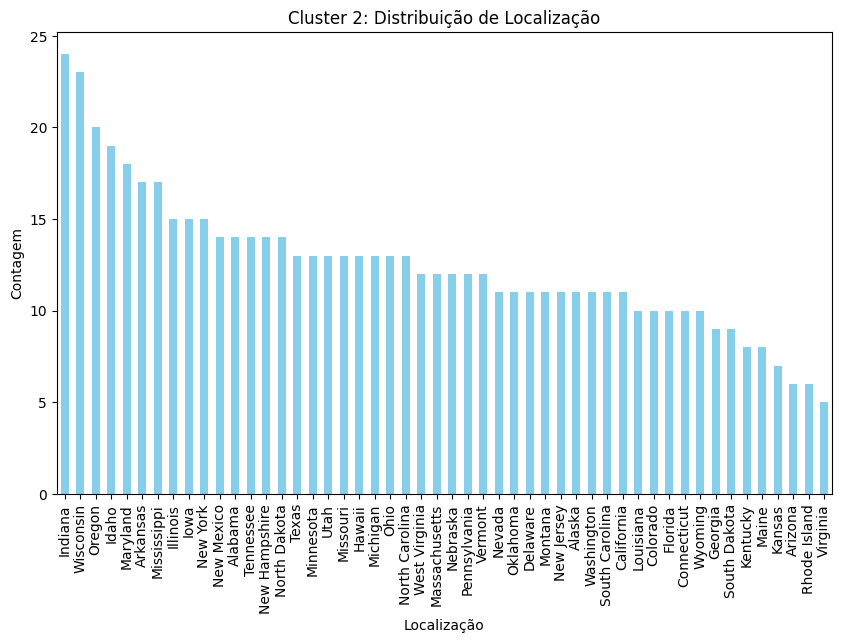

In [ ]:
# Contar a frequência de cada localização
frequencia_location = df2['Location'].value_counts()

# Plotar o gráfico de colunas
plt.figure(figsize=(10, 6))
frequencia_location.plot(kind='bar', color='skyblue')
plt.title('Cluster 2: Distribuição de Localização')
plt.xlabel('Localização')
plt.ylabel('Contagem')
plt.xticks(rotation=90)
plt.show()

In [ ]:
# Analisando amostra de acordo com os 4 estados com mais compras

estados = ['Indiana', 'Wisconsin', 'Oregon', 'Idaho']

df2_amostra = df2[df2['Location'].isin(estados)]

df2_amostra.describe()

,Age,Purchase Amount (USD),Review Rating,Previous Purchases,Cluster
count,86.000000,86.000000,86.000000,86.000000,86.0
mean,44.639535,62.290698,3.890698,24.325581,2.0
std,15.941004,22.911013,0.707211,16.702548,0.0
min,18.000000,20.000000,2.600000,1.000000,2.0
25%,29.250000,43.000000,3.400000,8.000000,2.0
50%,44.000000,64.000000,4.000000,23.000000,2.0
75%,58.750000,81.000000,4.400000,41.000000,2.0
max,70.000000,100.000000,5.000000,50.000000,2.0


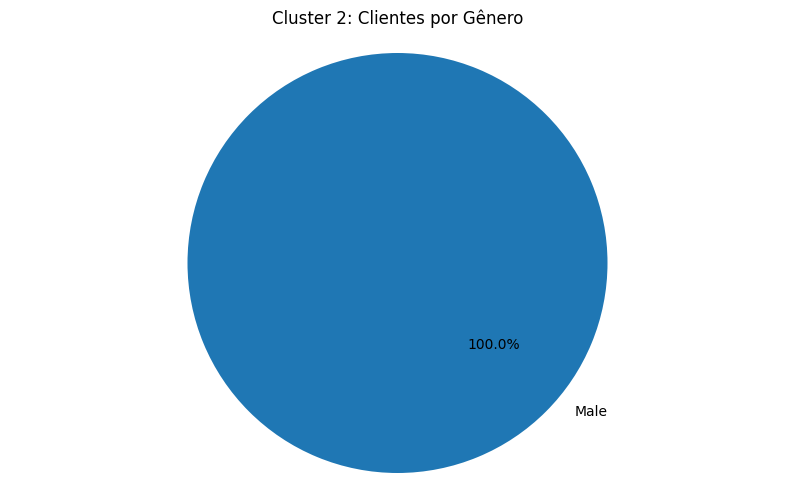

In [ ]:
# Contar a frequência de cada gênero
frequencia_genero = df2_amostra['Gender'].value_counts()

# Plotar o gráfico de pizza
plt.figure(figsize=(10, 6))
plt.pie(frequencia_genero, labels=frequencia_genero.index, autopct='%1.1f%%', startangle=140)
plt.title('Cluster 2: Clientes por Gênero')
plt.axis('equal')
plt.show()

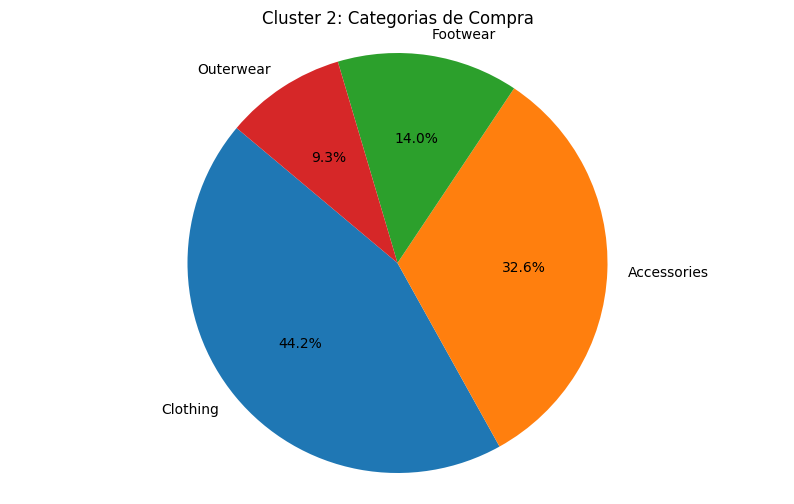

In [ ]:
# Contar a frequência de cada Categoria
frequencia_categoria = df2_amostra['Category'].value_counts()

# Plotar o gráfico de pizza
plt.figure(figsize=(10, 6))
plt.pie(frequencia_categoria, labels=frequencia_categoria.index, autopct='%1.1f%%', startangle=140)
plt.title('Cluster 2: Categorias de Compra')
plt.axis('equal')
plt.show()

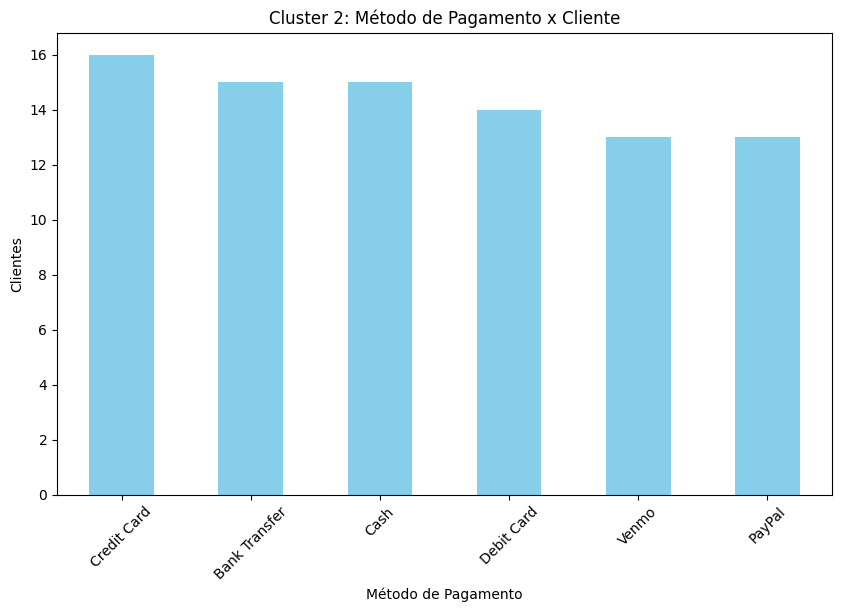

In [ ]:
# Contar a frequência de cada Método de Pagamento
frequencia_pagamento = df2_amostra['Payment Method'].value_counts()

# Plotar o gráfico de colunas
plt.figure(figsize=(10, 6))
frequencia_pagamento.plot(kind='bar', color='skyblue')
plt.title('Cluster 2: Método de Pagamento x Cliente')
plt.xlabel('Método de Pagamento')
plt.ylabel('Clientes')
plt.xticks(rotation=45)
plt.show()

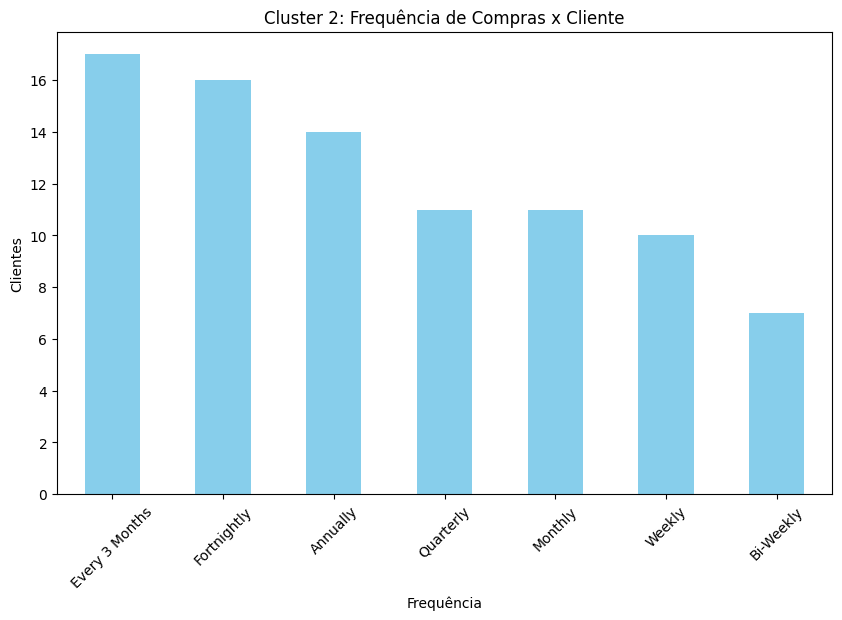

In [ ]:
# Contar a frequência de Compra
frequencia_compra = df2_amostra['Frequency of Purchases'].value_counts()

# Plotar o gráfico de colunas
plt.figure(figsize=(10, 6))
frequencia_compra.plot(kind='bar', color='skyblue')
plt.title('Cluster 2: Frequência de Compras x Cliente')
plt.xlabel('Frequência')
plt.ylabel('Clientes')
plt.xticks(rotation=45)
plt.show()

### Cluster 3

O Cluster 3, com 1053 consumidores, são mais presentes nos seguintes estados: California, Delaware, Nevada, West Virginia. Eles representam um perfil de consumidores composto por homens com idade média de 41 anos. Estes consumidores realizaram, em média, 25 compras anteriormente, com um ticket médio de $ 63,06 por compra. Entretanto, é importante ressaltar o alto índice do desvio padrão para estas variáveis. A avaliação média dada por este grupo é de 3,74 estrelas. O método de pagamento preferido é o Venmo. As categorias de produtos mais compradas são roupas, 43.5%, seguidas por acessórios, 37,4%. Este grupo costuma utilizar descontos, cupons e também se inscreve em promoções. A maioria dos consumidores deste perfil realiza compras mensalmente.

In [ ]:
df3.head()

,Age,Gender,Category,Purchase Amount (USD),Location,Review Rating,Subscription Status,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases,Cluster
0,55,Male,Clothing,53,Kentucky,3.1,Yes,Yes,Yes,14,Venmo,Fortnightly,3
1,19,Male,Clothing,64,Maine,3.1,Yes,Yes,Yes,2,Cash,Fortnightly,3
2,50,Male,Clothing,73,Massachusetts,3.1,Yes,Yes,Yes,23,Credit Card,Weekly,3
3,21,Male,Footwear,90,Rhode Island,3.5,Yes,Yes,Yes,49,PayPal,Weekly,3
4,45,Male,Clothing,49,Oregon,2.7,Yes,Yes,Yes,31,PayPal,Annually,3


In [ ]:
df3.describe()

,Age,Purchase Amount (USD),Review Rating,Previous Purchases,Cluster
count,1053.000000,1053.000000,1053.000000,1053.000000,1053.0
mean,44.230769,59.491928,3.742450,26.084520,3.0
std,15.038194,23.449914,0.717974,14.138488,0.0
min,18.000000,20.000000,2.500000,1.000000,3.0
25%,31.000000,39.000000,3.100000,14.000000,3.0
50%,45.000000,60.000000,3.700000,26.000000,3.0
75%,57.000000,80.000000,4.400000,38.000000,3.0
max,70.000000,100.000000,5.000000,50.000000,3.0


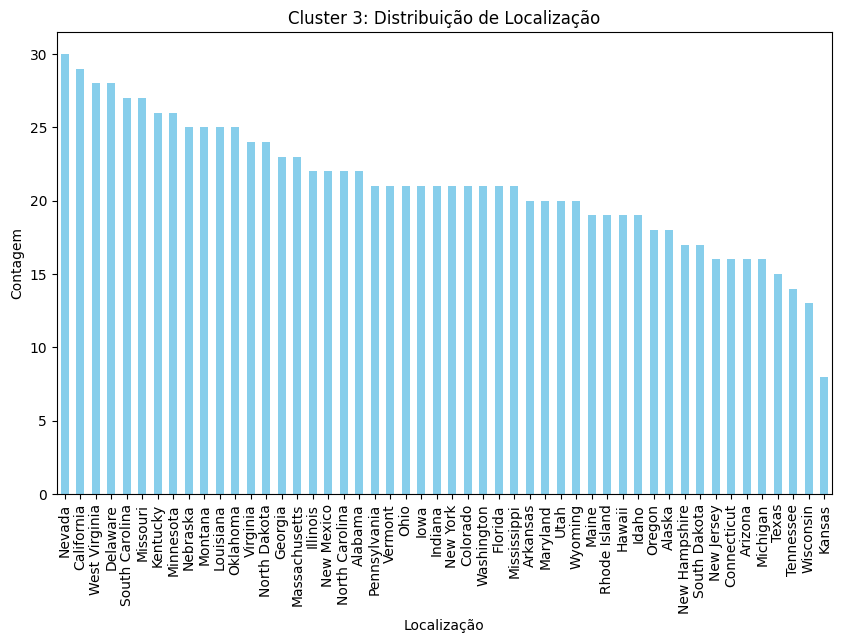

In [ ]:
# Contar a frequência de cada localização
frequencia_location = df3['Location'].value_counts()

# Plotar o gráfico de colunas
plt.figure(figsize=(10, 6))
frequencia_location.plot(kind='bar', color='skyblue')
plt.title('Cluster 3: Distribuição de Localização')
plt.xlabel('Localização')
plt.ylabel('Contagem')
plt.xticks(rotation=90)
plt.show()

In [ ]:
# Analisando amostra de acordo com os 4 estados com mais compras

estados = ['Nevada', 'California', 'West Virginia', 'Delaware']

df3_amostra = df3[df3['Location'].isin(estados)]

df3_amostra.describe()

,Age,Purchase Amount (USD),Review Rating,Previous Purchases,Cluster
count,115.000000,115.000000,115.000000,115.000000,115.0
mean,41.469565,63.060870,3.737391,24.895652,3.0
std,14.318631,23.067136,0.709517,13.618469,0.0
min,19.000000,20.000000,2.500000,1.000000,3.0
25%,30.000000,42.500000,3.200000,13.500000,3.0
50%,40.000000,66.000000,3.700000,24.000000,3.0
75%,54.000000,82.500000,4.400000,34.500000,3.0
max,70.000000,100.000000,5.000000,50.000000,3.0


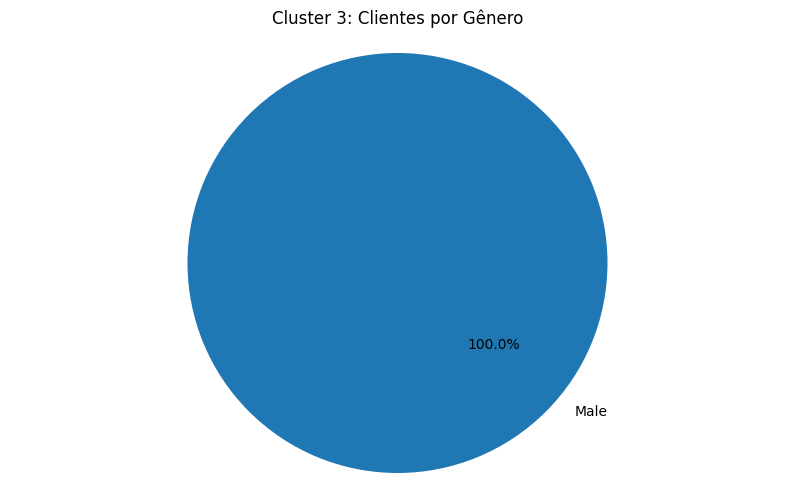

In [ ]:
# Contar a frequência de cada gênero
frequencia_genero = df3_amostra['Gender'].value_counts()

# Plotar o gráfico de pizza
plt.figure(figsize=(10, 6))
plt.pie(frequencia_genero, labels=frequencia_genero.index, autopct='%1.1f%%', startangle=140)
plt.title('Cluster 3: Clientes por Gênero')
plt.axis('equal')
plt.show()

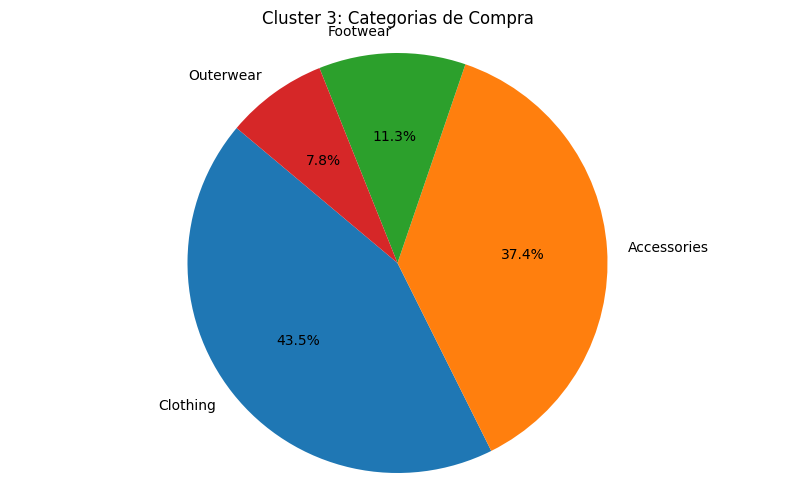

In [ ]:
# Contar a frequência de cada Categoria
frequencia_categoria = df3_amostra['Category'].value_counts()

# Plotar o gráfico de pizza
plt.figure(figsize=(10, 6))
plt.pie(frequencia_categoria, labels=frequencia_categoria.index, autopct='%1.1f%%', startangle=140)
plt.title('Cluster 3: Categorias de Compra')
plt.axis('equal')
plt.show()

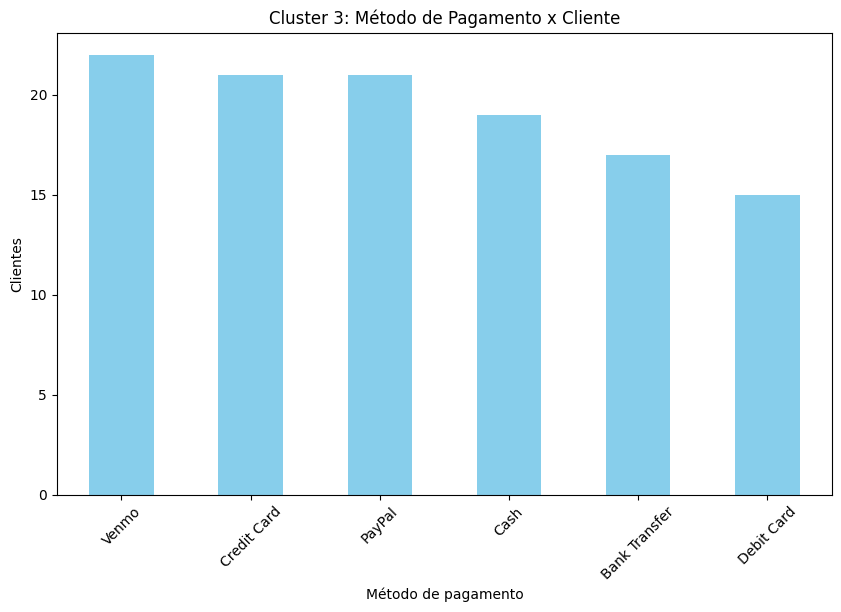

In [ ]:
# Contar a frequência de cada Método de Pagamento
frequencia_pagamento = df3_amostra['Payment Method'].value_counts()

# Plotar o gráfico de colunas
plt.figure(figsize=(10, 6))
frequencia_pagamento.plot(kind='bar', color='skyblue')
plt.title('Cluster 3: Método de Pagamento x Cliente')
plt.xlabel('Método de pagamento')
plt.ylabel('Clientes')
plt.xticks(rotation=45)
plt.show()

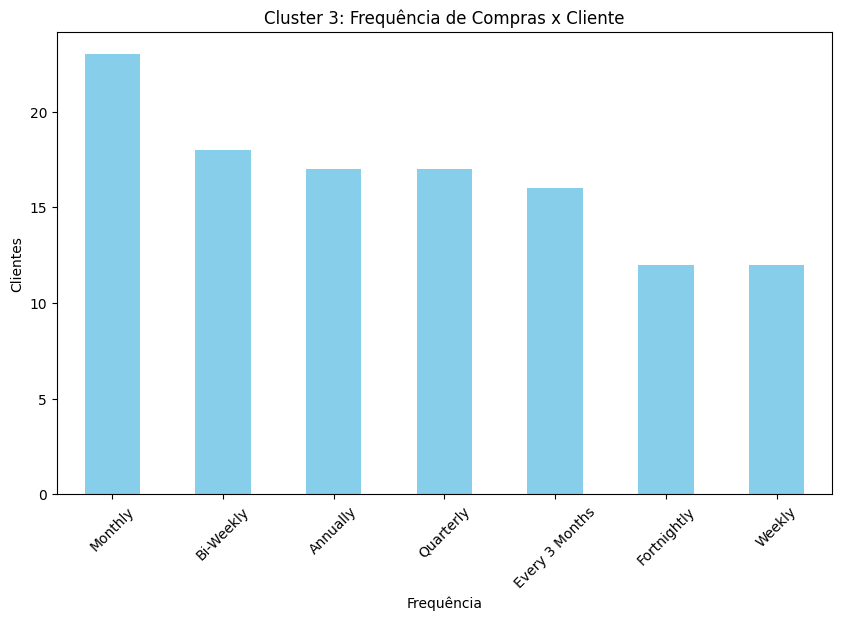

In [ ]:
# Contar a frequência de Compra
frequencia_compra = df3_amostra['Frequency of Purchases'].value_counts()

# Plotar o gráfico de colunas
plt.figure(figsize=(10, 6))
frequencia_compra.plot(kind='bar', color='skyblue')
plt.title('Cluster 3: Frequência de Compras x Cliente')
plt.xlabel('Frequência')
plt.ylabel('Clientes')
plt.xticks(rotation=45)
plt.show()

## Conclusão


O Cluster 0 representa clientes leais que fazem compras frequentes e têm uma alta propensão a gastar. As estratégias de marketing para este grupo devem focar em lançamentos de novos produtos e promoções exclusivas para manter o engajamento. Já o Cluster 1 , composto por clientes femininas, é consistente em suas compras e prefere usar cartão de crédito. As campanhas de marketing devem destacar a conveniência e a segurança das transações, além de oferecer coleções exclusivas para manter a fidelidade. Além disso , o Cluster 2 é sensível a
preços e promoções, o que sugere que campanhas de descontos e cupons trimestrais podem ser muito eficazes. É importante também oferecer uma boa variedade de produtos para manter o interesse dos clientes entre as compras. Por fim , o Cluster 3 é altamente engajado com promoções e descontos, além de estar aberto a novas tecnologias de pagamento como Venmo. As campanhas de marketing devem focar em ofertas mensais e promoções dinâmicas para manter a lealdade e incentivar compras recorrentes.

Resultados que podem ser interpretados no contexto de marketing após essa pesquisa :

● Segmentação personalizada: Cada cluster tem características e preferências distintas, permitindo campanhas de marketing mais direcionadas e personalizadas.

● Geografia como fator crítico: A distribuição geográfica dos clientes revela
mercados-chave que podem ser alvos de campanhas publicitárias intensivas e
expansão de lojas físicas.

● Preferências de pagamento: A diversificação das opções de pagamento pode melhorar
a experiência do cliente e aumentar as taxas de conversão.

● Promoções e fidelidade: A implementação de programas de fidelidade e ofertas
personalizadas pode aumentar a retenção de clientes e o valor vitalício do cliente.

● Oportunidades de expansão: Identificar novos mercados potenciais e ajustar a oferta
de produtos para melhor atender às necessidades específicas de cada segmento de
clientes.

A personalização das campanhas, a focalização nos mercados chave, e o investimento em programas de fidelidade são algumas das ações que podem ser tomadas para aumentar a eficácia do marketing, melhorar a experiência do cliente e impulsionar o crescimento da empresa.